<a href="https://colab.research.google.com/github/agrawalreva/idx-exchange-ds34/blob/main/Light_GBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


In [67]:
df = pd.read_csv("final_training.csv", nrows = 1000)

In [68]:
df['CloseDate'] = pd.to_datetime(df['CloseDate'])
df['close_month'] = df['CloseDate'].dt.month
df['close_year'] = df['CloseDate'].dt.year
df['property_age'] = 2025 - df['YearBuilt']
df['zipcode_median_price_per_sqft'] = (
    df.groupby('PostalCode')['ClosePrice'].transform('median') /
    df.groupby('PostalCode')['LivingArea'].transform('median')
)

def evaluate_model(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{label} Metrics:")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  MAPE: {mape:.2f}%")
    return rmse, r2, mae, mape



LightGBM Model (Single Feature)
Predicting ClosePrice using: LivingArea


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Single-Feature Training Metrics:
  RMSE: $1,040,630.57
  R²: 0.4749
  MAE: $718,524.50
  MAPE: 52.85%

Single-Feature Testing Metrics:
  RMSE: $1,125,063.05
  R²: 0.2297
  MAE: $813,567.70
  MAPE: 68.57%


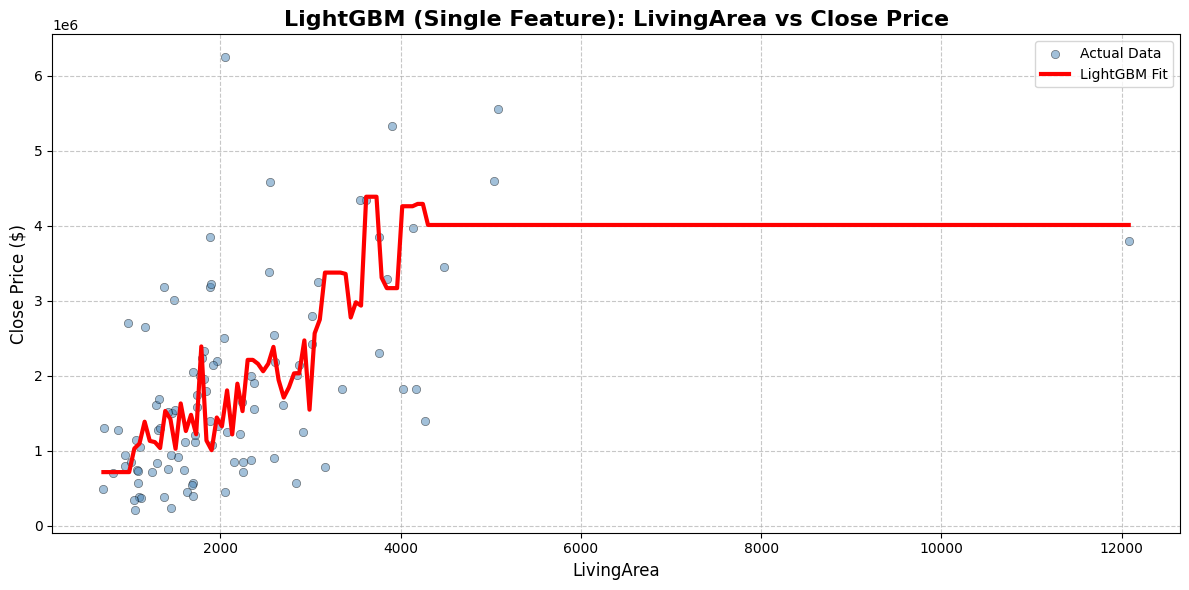

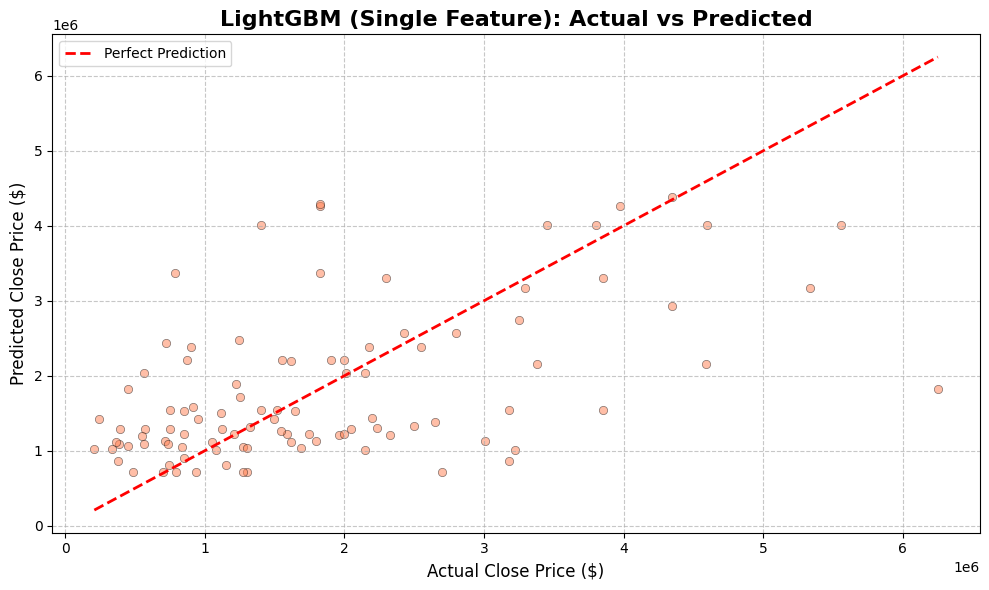

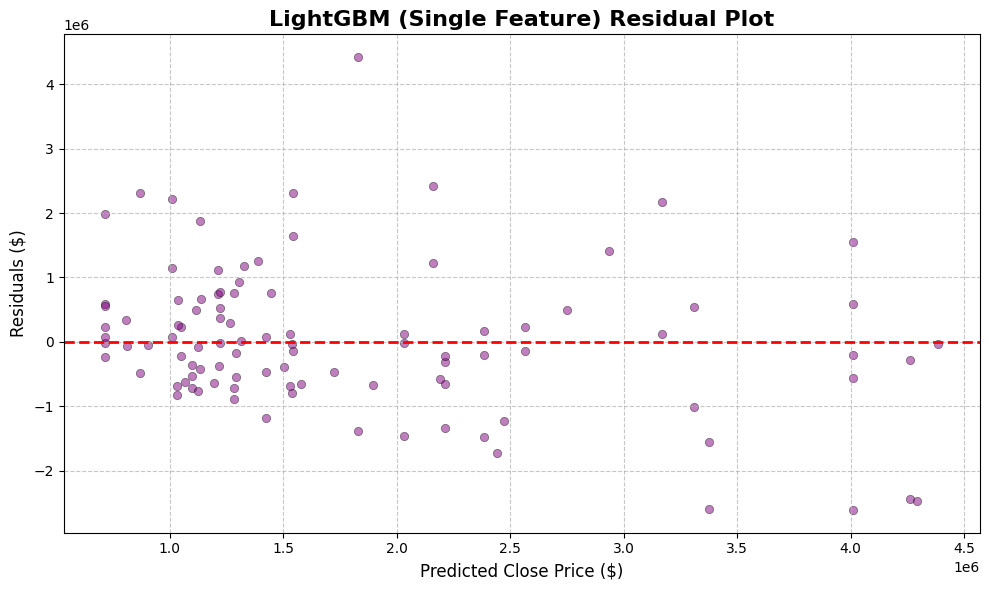


LightGBM single-feature model complete!
Predictions saved to 'lightgbm_LivingArea_single_feature_predictions.csv'


In [57]:
# 1) SINGLE-FEATURE LIGHTGBM: LivingArea → ClosePrice
feature_name = 'LivingArea'

print("\nLightGBM Model (Single Feature)")
print("Predicting ClosePrice using:", feature_name)
print("="*60)

X_single = df[[feature_name]].copy()
y_single = df['ClosePrice'].copy()

X_single = X_single.fillna(X_single.median())
y_single = y_single.fillna(y_single.median())
X_single = X_single.dropna()
y_single = y_single[X_single.index]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s_scaled = scaler.fit_transform(X_train_s)
X_test_s_scaled = scaler.transform(X_test_s)

model_single = LGBMRegressor(
    n_estimators=450,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    max_depth=-1,
    random_state=42,
    verbose=-1
)
model_single.fit(X_train_s_scaled, y_train_s)

y_train_pred_s = model_single.predict(X_train_s_scaled)
y_test_pred_s = model_single.predict(X_test_s_scaled)

train_rmse_s, train_r2_s, train_mae_s, train_mape_s  = evaluate_model(
    y_train_s, y_train_pred_s, "Single-Feature Training"
)
test_rmse_s, test_r2_s, test_mae_s, test_mape_s = evaluate_model(
    y_test_s, y_test_pred_s, "Single-Feature Testing"
)

plt.figure(figsize=(12, 6))
plt.scatter(X_test_s, y_test_s, alpha=0.5, color='steelblue', edgecolors='black', linewidth=0.5, label='Actual Data')

X_range = np.linspace(X_test_s.min(), X_test_s.max(), 200).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
y_pred_curve = model_single.predict(X_range_scaled)
plt.plot(X_range, y_pred_curve, 'r-', linewidth=3, label='LightGBM Fit')

plt.xlabel(feature_name, fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.title(f'LightGBM (Single Feature): {feature_name} vs Close Price', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test_s, y_test_pred_s, alpha=0.5, color='coral', edgecolors='black', linewidth=0.5)
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Close Price ($)', fontsize=12)
plt.ylabel('Predicted Close Price ($)', fontsize=12)
plt.title('LightGBM (Single Feature): Actual vs Predicted', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

residuals_s = y_test_s - y_test_pred_s
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_s, residuals_s, alpha=0.5, color='purple', edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Close Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('LightGBM (Single Feature) Residual Plot', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

results_single = pd.DataFrame({
    feature_name: X_test_s.values.flatten(),
    'Actual_Price': y_test_s.values,
    'Predicted_Price': y_test_pred_s,
    'Residual': residuals_s
})
results_single.to_csv(f'lightgbm_{feature_name}_single_feature_predictions.csv', index=False)

print("\nLightGBM single-feature model complete!")
print(f"Predictions saved to 'lightgbm_{feature_name}_single_feature_predictions.csv'")


LightGBM Model (Full Feature Set)
Predicting ClosePrice using: all available predictors

Full-Feature Training Metrics:
  RMSE: $84,131.77
  R²: 0.9956
  MAE: $33,570.07
  MAPE: 2.03%

Full-Feature Testing Metrics:
  RMSE: $466,602.27
  R²: 0.8441
  MAE: $282,335.40
  MAPE: 20.67%


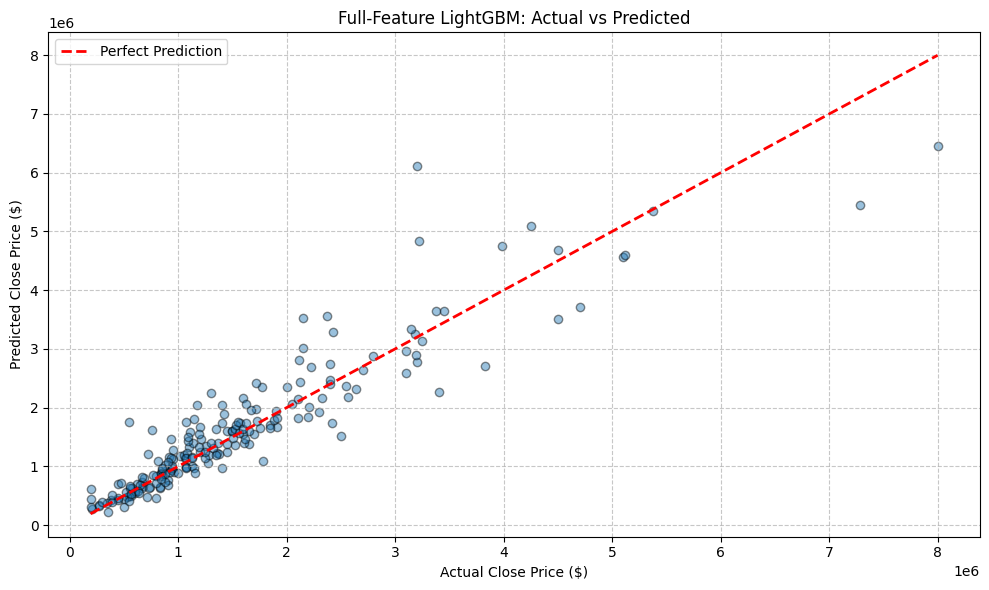

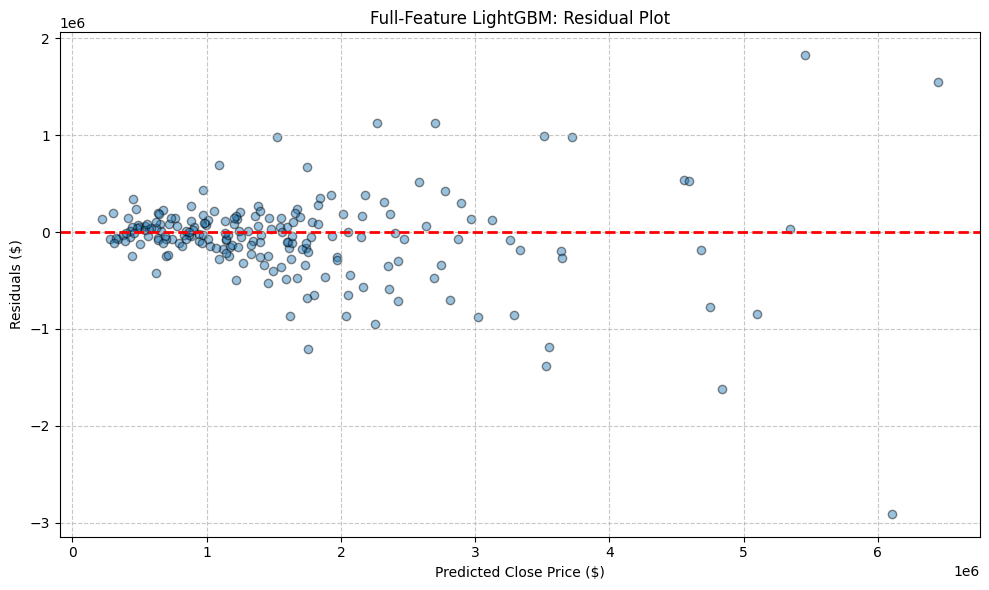

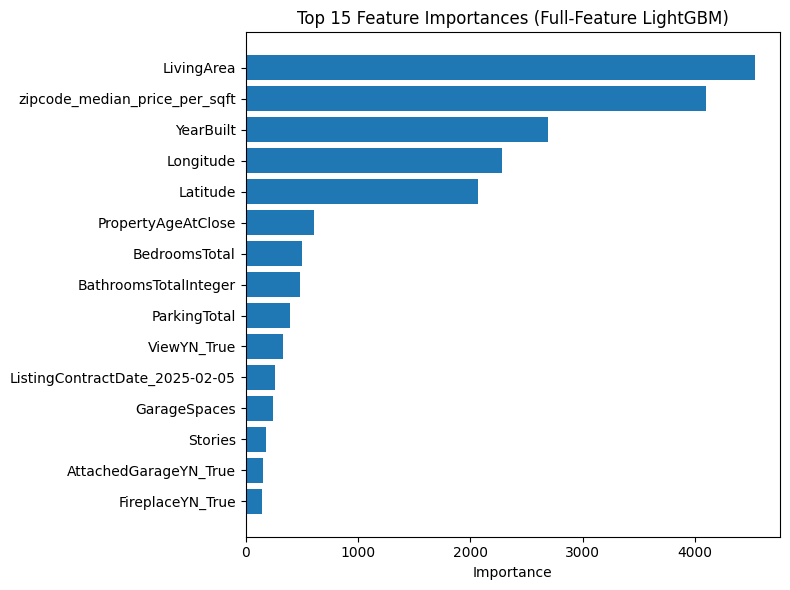


Full-feature LightGBM complete!
Predictions saved to 'lightgbm_full_feature_results.csv'


In [69]:

# 2) FULL-FEATURE LIGHTGBM: all dataset features + engineering

print("\nLightGBM Model (Full Feature Set)")
print("Predicting ClosePrice using: all available predictors")
print("="*60)

y_full = df['ClosePrice'].astype(float)
X_full = df.drop(columns=['ClosePrice', 'CloseDate'])

num_cols = X_full.select_dtypes(include=[np.number]).columns
cat_cols = X_full.select_dtypes(exclude=[np.number]).columns

X_full[num_cols] = X_full[num_cols].fillna(X_full[num_cols].median())
for c in cat_cols:
    X_full[c] = X_full[c].fillna("Missing")

X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=True)

y_full = y_full.fillna(y_full.median())
X_full = X_full.loc[y_full.index]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

model_full = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

model_full.fit(X_train_f, y_train_f)

y_train_pred_f = model_full.predict(X_train_f)
y_test_pred_f = model_full.predict(X_test_f)

train_rmse_f, train_r2_f, train_mae_f, train_mape_f = evaluate_model(
    y_train_f, y_train_pred_f, "Full-Feature Training"
)
test_rmse_f, test_r2_f, test_mae_f, test_mape_f = evaluate_model(
    y_test_f, y_test_pred_f, "Full-Feature Testing"
)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_f, y_test_pred_f, alpha=0.45, edgecolors='black')
plt.plot([y_test_f.min(), y_test_f.max()],
         [y_test_f.min(), y_test_f.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Full-Feature LightGBM: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

resid_f = y_test_f - y_test_pred_f
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_f, resid_f, alpha=0.45, edgecolors='black')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Close Price ($)")
plt.ylabel("Residuals ($)")
plt.title("Full-Feature LightGBM: Residual Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

fi = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": model_full.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(fi["Feature"][::-1], fi["Importance"][::-1])
plt.title("Top 15 Feature Importances (Full-Feature LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

results_full = pd.DataFrame({
    "Actual_Price": y_test_f.values,
    "Predicted_Price": y_test_pred_f,
    "Residual": resid_f
})
results_full.to_csv("lightgbm_full_feature_results.csv", index=False)

print("\nFull-feature LightGBM complete!")
print("Predictions saved to 'lightgbm_full_feature_results.csv'")

In [70]:
# 3) SUMMARY TABLE OF MODEL PERFORMANCE

summary_rows = [
    {
        "Model": "Single-Feature LightGBM",
        "Split": "Train",
        "RMSE": train_rmse_s,
        "R2": train_r2_s,
        "MAE": train_mae_s,
        "MAPE": train_mape_s,
    },
    {
        "Model": "Single-Feature LightGBM",
        "Split": "Test",
        "RMSE": test_rmse_s,
        "R2": test_r2_s,
        "MAE": test_mae_s,
        "MAPE": test_mape_s,
    },
    {
        "Model": "Full-Feature LightGBM",
        "Split": "Train",
        "RMSE": train_rmse_f,
        "R2": train_r2_f,
        "MAE": train_mae_f,
        "MAPE": train_mape_f,
    },
    {
        "Model": "Full-Feature LightGBM",
        "Split": "Test",
        "RMSE": test_rmse_f,
        "R2": test_r2_f,
        "MAE": test_mae_f,
        "MAPE": test_mape_f,
    },
]

summary_df = pd.DataFrame(summary_rows)

print("\n========== Model Comparison Summary ==========")
print(summary_df)

summary_df.to_csv("lightgbm_model_comparison_summary.csv", index=False)
print("\nModel comparison table saved to 'lightgbm_model_comparison_summary.csv'")



========== Model Comparison Summary ==========
                     Model  Split          RMSE        R2            MAE  \
0  Single-Feature LightGBM  Train  1.040631e+06  0.474851  718524.499258   
1  Single-Feature LightGBM   Test  1.125063e+06  0.229729  813567.703305   
2    Full-Feature LightGBM  Train  8.413177e+04  0.995592   33570.073950   
3    Full-Feature LightGBM   Test  4.666023e+05  0.844112  282335.401673   

        MAPE  
0  52.854302  
1  68.565805  
2   2.034067  
3  20.666324  

Model comparison table saved to 'lightgbm_model_comparison_summary.csv'



Number of numeric features: 14
Number of categorical features: 11


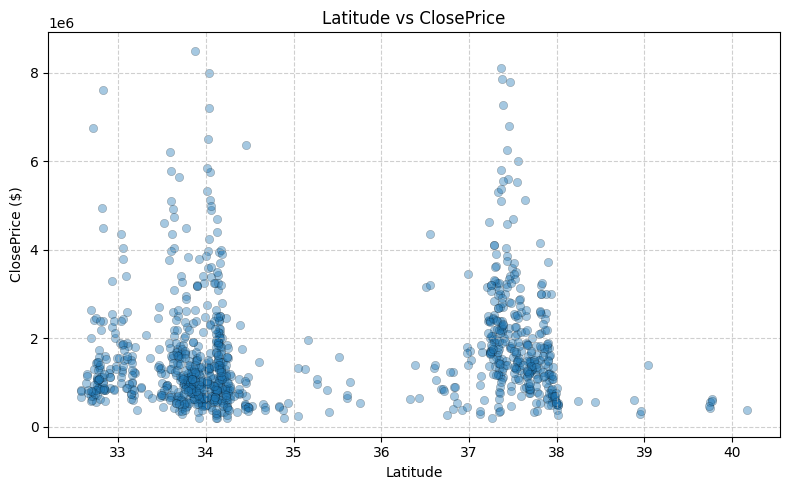

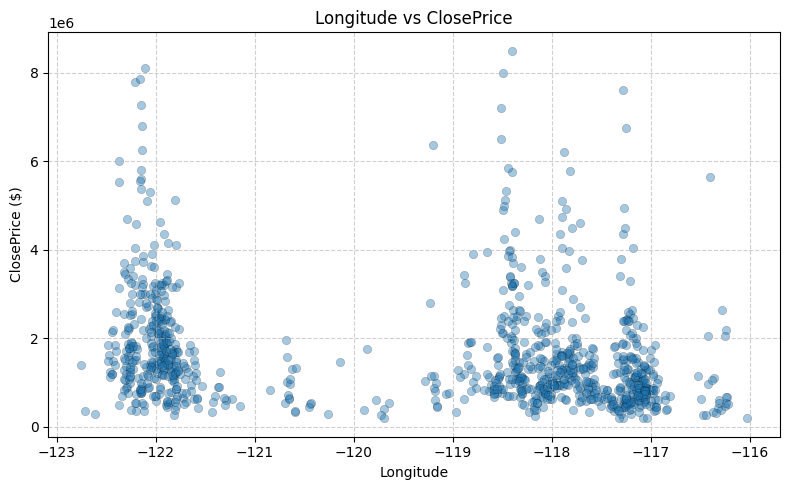

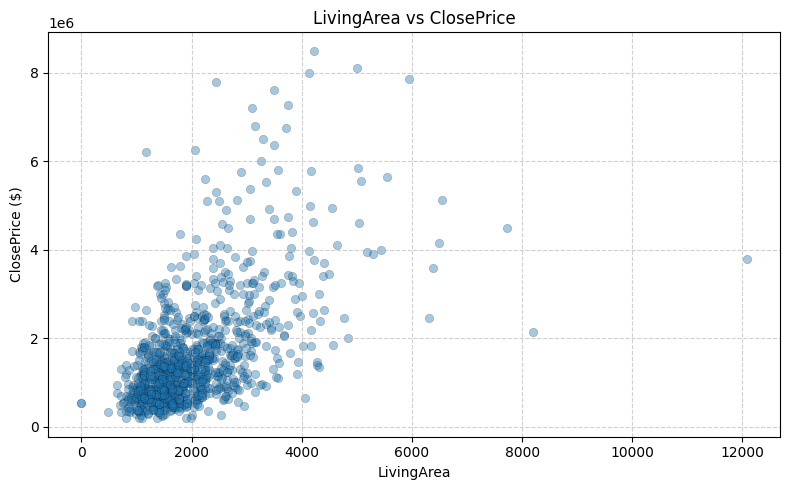

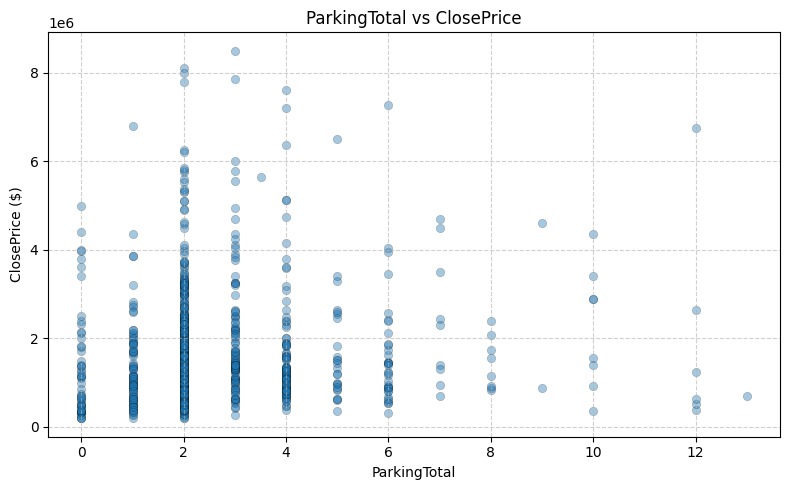

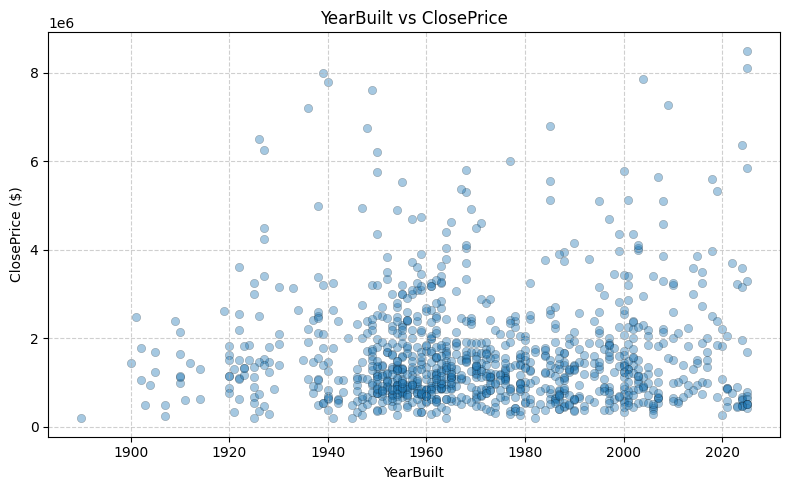

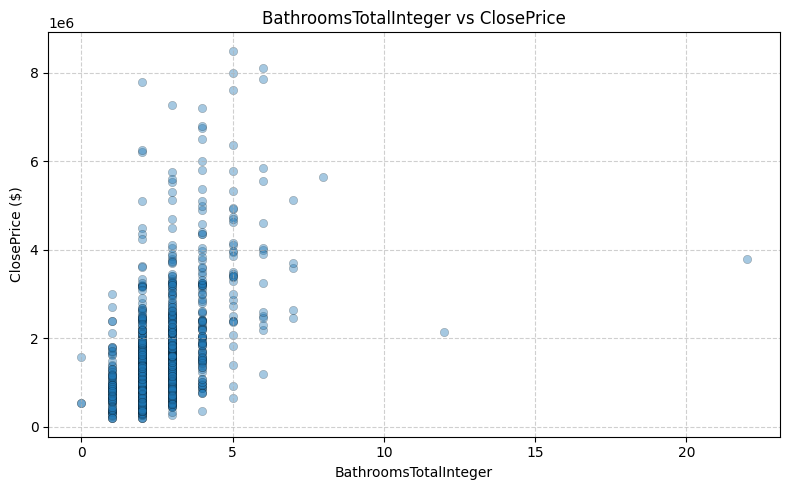

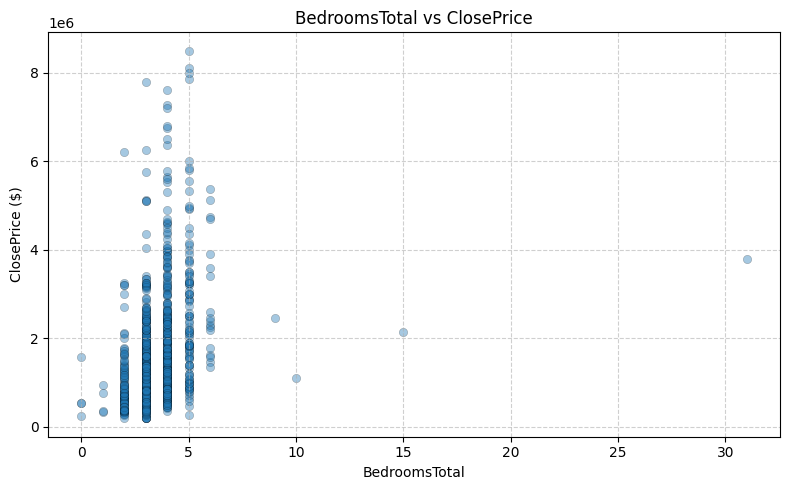

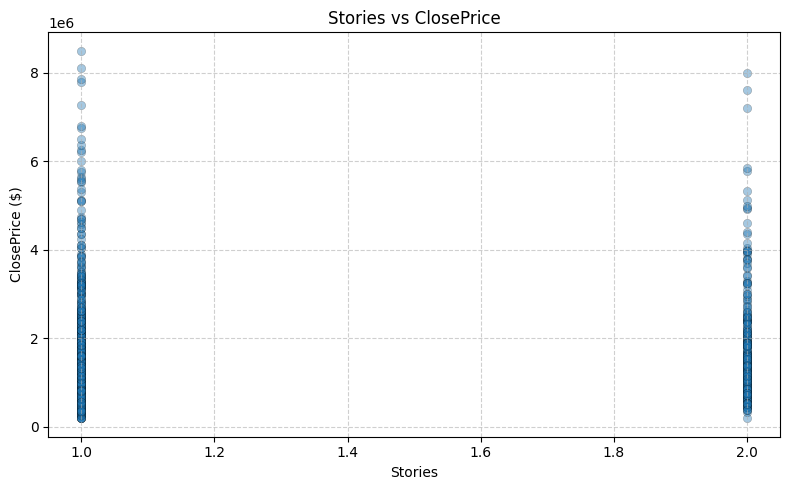

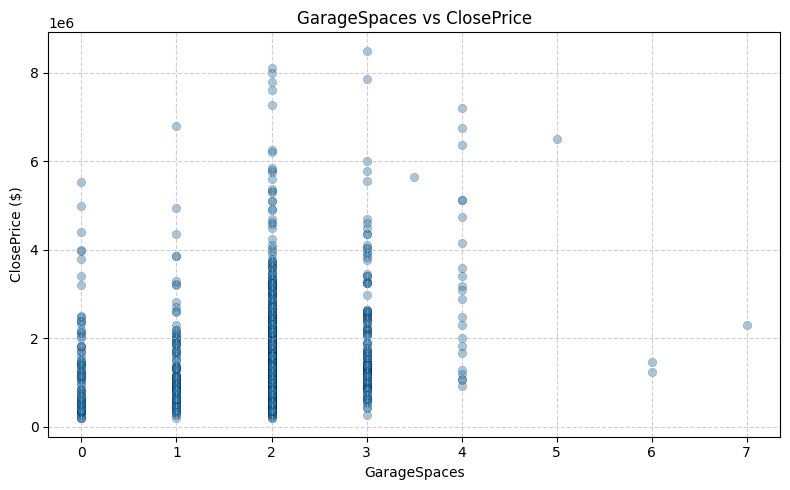

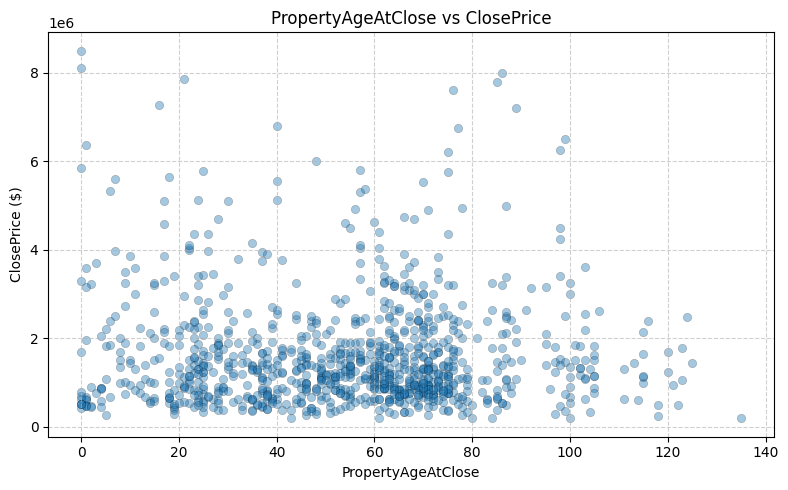

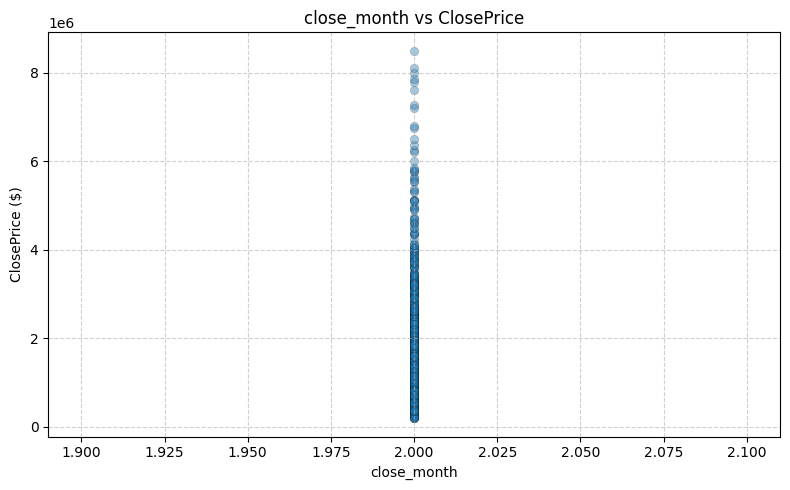

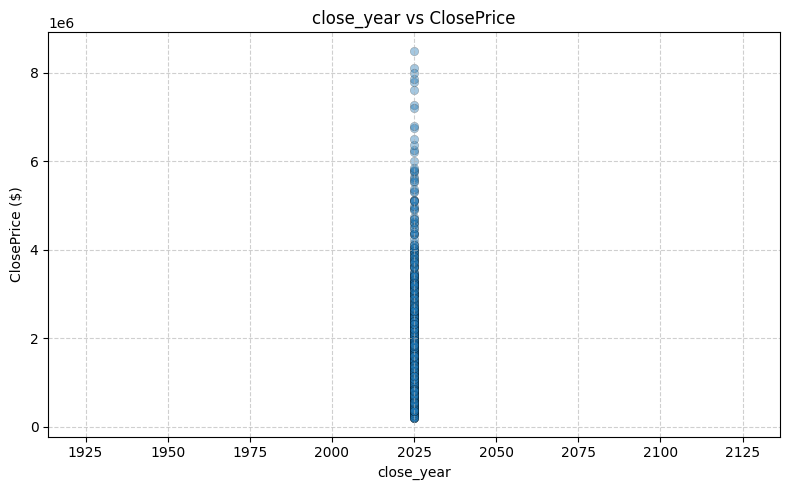

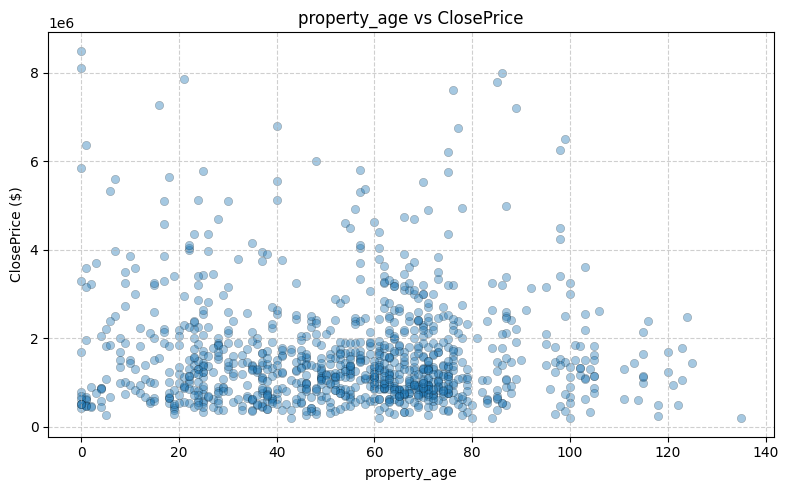

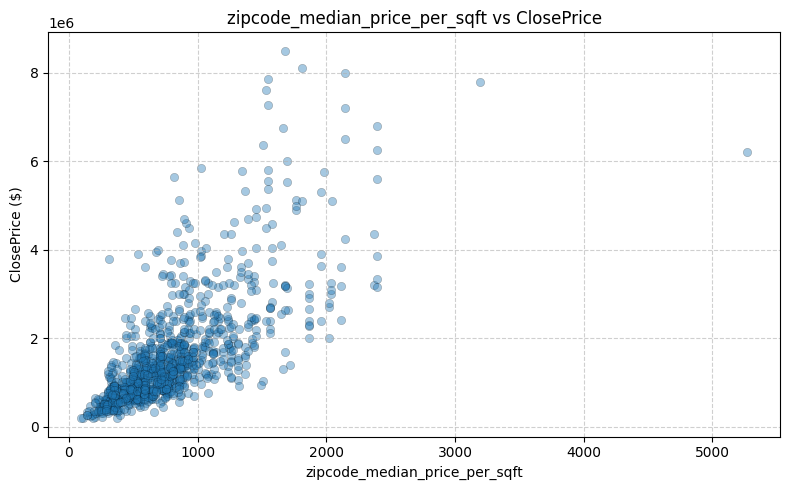

<Figure size 1000x500 with 0 Axes>

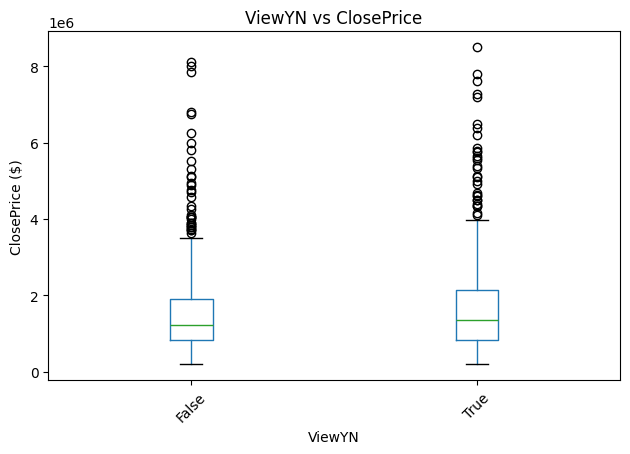

<Figure size 1000x500 with 0 Axes>

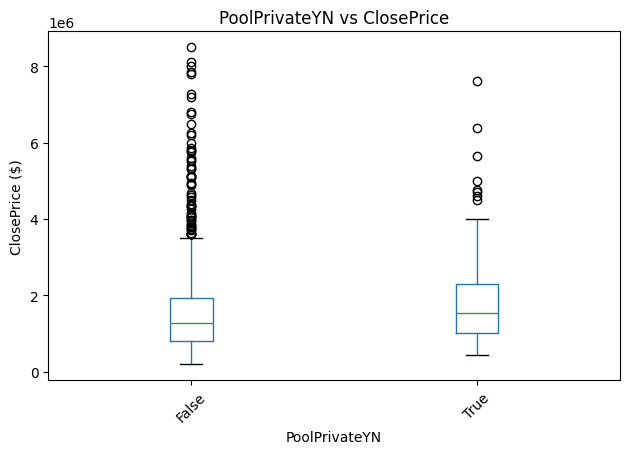

<Figure size 1000x500 with 0 Axes>

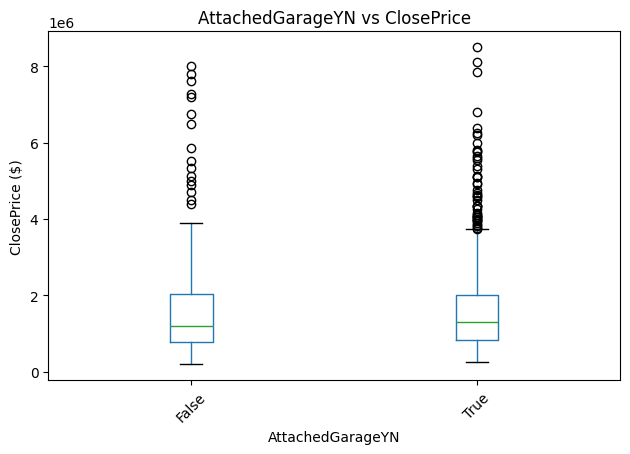

<Figure size 1000x500 with 0 Axes>

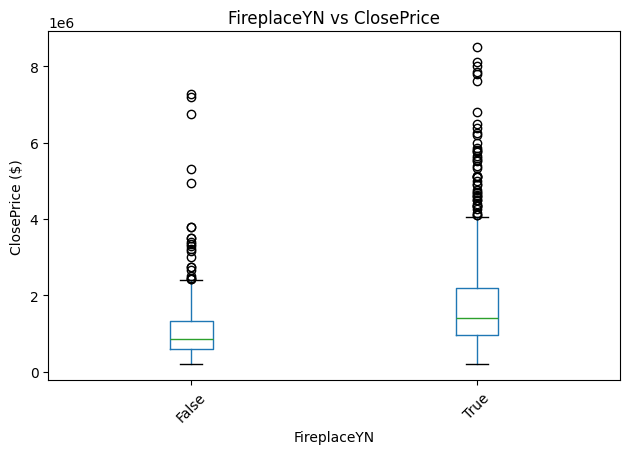

<Figure size 1000x500 with 0 Axes>

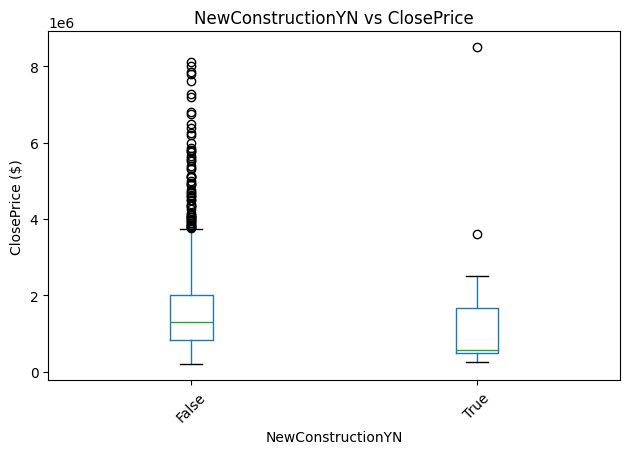

In [71]:

# 4) ORIGINAL FEATURES vs ClosePrice (numeric + categorical)

raw_feature_cols = df.drop(columns=['ClosePrice', 'CloseDate']).columns

num_features = df[raw_feature_cols].select_dtypes(include=[np.number]).columns
cat_features = df[raw_feature_cols].select_dtypes(exclude=[np.number]).columns

print("\nNumber of numeric features:", len(num_features))
print("Number of categorical features:", len(cat_features))

#numeric
for f in num_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[f], df['ClosePrice'], alpha=0.4, edgecolors='black', linewidth=0.3)
    plt.xlabel(f)
    plt.ylabel('ClosePrice ($)')
    plt.title(f'{f} vs ClosePrice')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

#categorical
for f in cat_features:
    if df[f].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        df.boxplot(column='ClosePrice', by=f, grid=False, rot=45)
        plt.title(f'{f} vs ClosePrice')
        plt.suptitle("")
        plt.xlabel(f)
        plt.ylabel('ClosePrice ($)')
        plt.tight_layout()
        plt.show()


Replace `some_library` with the actual name of the library you wish to install. You can also specify a particular version of the library using `some_library==1.2.3` or install multiple libraries at once by listing them: `pip install library1 library2`.